**DATA COLLECTION**

In [1]:
!pip install -qq google-play-scraper

In [3]:
!pip install -qq -U watermark

In [4]:
%reload_ext watermark
%watermark -v -p pandas,matplotlib,seaborn,google_play_scraper

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 8.25.0

pandas             : 2.2.2
matplotlib         : 3.8.4
seaborn            : 0.13.2
google_play_scraper: 1.2.7



In [5]:
import json
import pandas as pd
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

from pygments import highlight
from pygments.lexers import JsonLexer
from pygments.formatters import TerminalFormatter

from google_play_scraper import Sort, reviews, app

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette = 'muted', font_scale=1.2)

In [6]:
app_packages = [
  'in.startv.hotstar',
  'com.digilocker.android',
  'com.openai.chatgpt',
  'nic.goi.aarogyasetu',
  'in.gov.uidai.mAadhaarPlus',
  'com.snapchat.android',
  'com.instagram.android',
  'com.flipkart.android',
  'com.meesho.supply',
  'com.whatsapp',
  'com.truecaller',
  'com.facebook.katana',
  'org.telegram.messenger',
  'net.one97.paytm',
  'com.myntra.android',
  'com.canva.editor'
]

In [7]:
len(app_packages)

16

In [8]:
app_infos = []

for ap in tqdm(app_packages):
  info = app(ap, lang='en', country='in')
  del info['comments']
  app_infos.append(info)

100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:17<00:00,  1.09s/it]


In [15]:
def print_json(json_object):
  json_str = json.dumps(
    json_object,
    indent=2,
    sort_keys=True,
    default=str
  )
  print(highlight(json_str, JsonLexer(), TerminalFormatter()))

In [16]:
print_json(app_infos[0])

{
  "adSupported": true,
  "appId": "in.startv.hotstar",
  "categories": [
    {
      "id": "ENTERTAINMENT",
      "name": "Entertainment"
    }
  ],
  "containsAds": true,
  "contentRating": "Rated for 12+",
  "contentRatingDescription": "Parental Guidance Recommended",
  "currency": "INR",
  "description": "Disney+ Hotstar is now JioHotstar! Welcome to the world of infinite possibilities \u2013 where non-stop sports, endless entertainment, and countless stories come alive!\r\n\r\nStream the biggest live sports and cricketing action, catch the latest Bollywood, Hollywood and regional blockbusters, binge on hit TV shows before they air on TV, and dive into exclusive Hotstar Specials created just for you. You can also enjoy global hits from HBO, Peacock, and Paramount and explore the magic of Disney, Pixar, Marvel, Star Wars, and National Geographic. Whatever you love to watch, you\u2019ll find it here\u2014all in one place, only on JioHotstar, the ultimate hub for explosive live sport

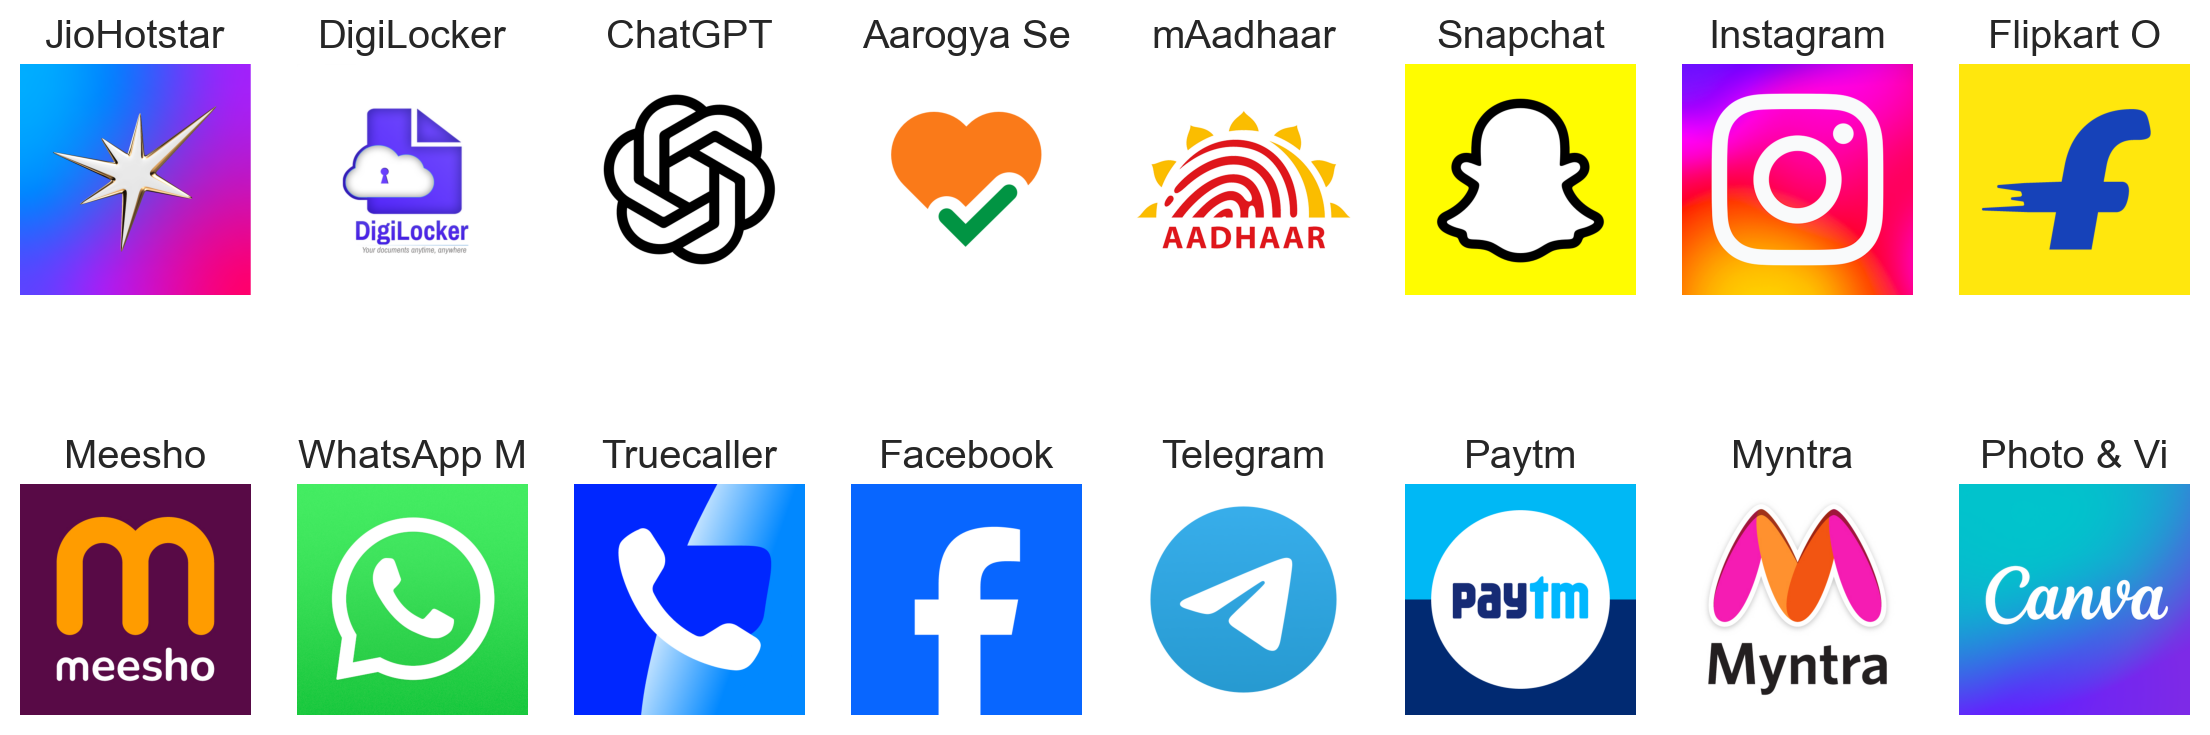

In [11]:
from PIL import Image
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

def format_title(title):
    sep_index = title.find(':') if title.find(':') != -1 else title.find('-')
    if sep_index != -1:
        title = title[:sep_index]
    return title[:10]

fig, axs = plt.subplots(2, len(app_infos) // 2, figsize=(14, 5))

for i, ax in enumerate(axs.flat):
    ai = app_infos[i]

    # Open the image using Pillow
    img = np.array(Image.open(urllib.request.urlopen(ai['icon'])))

    ax.imshow(img)
    ax.set_title(format_title(ai['title']))
    ax.axis('off')

plt.show()

In [12]:
app_infos_df = pd.DataFrame(app_infos)
app_infos_df.head(2)

,title,description,descriptionHTML,summary,installs,minInstalls,realInstalls,score,ratings,reviews,...,contentRating,contentRatingDescription,adSupported,containsAds,released,lastUpdatedOn,updated,version,appId,url
0,JioHotstar,Disney+ Hotstar is now JioHotstar! Welcome to ...,Disney+ Hotstar is now JioHotstar! Welcome to ...,Non-stop sports. Endless entertainment. Infini...,"500,000,000+",500000000,962345666,4.229281,12940690,3224718,...,Rated for 12+,Parental Guidance Recommended,True,True,"Jan 7, 2015","Jun 16, 2025",1750085887,Varies with device,in.startv.hotstar,https://play.google.com/store/apps/details?id=...
1,DigiLocker,DigiLocker is a key initiative under Digital I...,DigiLocker is a key initiative under Digital I...,DigiLocker - a simple and secure document wa...,"100,000,000+",100000000,128662139,4.202189,554607,157079,...,Rated for 3+,None,False,False,"Dec 23, 2015","Jun 15, 2025",1750047737,9.0.6,com.digilocker.android,https://play.google.com/store/apps/details?id=...


In [13]:
app_infos_df.to_csv('apps.csv', index=None, header=True)

In [14]:
from google_play_scraper.features.reviews import reviews, Sort

app_reviews = []

for ap in tqdm(app_packages):
    try:
        for score in range(1, 6):
            for sort_order in [Sort.MOST_RELEVANT, Sort.NEWEST]:
                reviews_data, app_info = reviews(
                    ap,
                    lang="en",
                    country="in",
                    sort=sort_order,
                    count=200 if score == 3 else 100,
                    filter_score_with=score
                )

                for r in reviews_data:
                    r['sortOrder'] = 'most_relevant' if sort_order == Sort.MOST_RELEVANT else 'newest'
                    r['appId'] = ap
                app_reviews.extend(reviews_data)
    except Exception as e:
        print(f"Error for app {ap}: {e}")
        continue


100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [02:33<00:00,  9.57s/it]


In [17]:
print_json(app_reviews[0])

{
  "appId": "in.startv.hotstar",
  "appVersion": "25.03.19.2",
  "at": "2025-05-07 23:29:40",
  "content": "This is the worst streaming app ever. Wayyy too many ads. Sure I understand ad plan could have an ad or two in a series episode. But 3-4 long unskippable series of ads in a single 20 minute episode even in the super plan. THE WORST. That's right 3-4 series of ads. Each break is a collection of 2-3 minutes of ad. I dread if something I want to watch is only available on this app. Just awful.",
  "repliedAt": null,
  "replyContent": null,
  "reviewCreatedVersion": "25.03.19.2",
  "reviewId": "eddcece8-a8cb-4f85-ac5f-b403865add68",
  "score": 1,
  "sortOrder": "most_relevant",
  "thumbsUpCount": 5023,
  "userImage": "https://play-lh.googleusercontent.com/a/ACg8ocLX8idEmK3cDL_F6X4ZfTyPY6at2g0lk_YYk4SatqkjgNRbyA=mo",
  "userName": "Samriddhi"
}



In [18]:
app_reviews_df = pd.DataFrame(app_reviews)
app_reviews_df.shape

(19200, 13)

In [19]:
app_reviews_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sortOrder,appId
0,eddcece8-a8cb-4f85-ac5f-b403865add68,Samriddhi,https://play-lh.googleusercontent.com/a/ACg8oc...,This is the worst streaming app ever. Wayyy to...,1,5023,25.03.19.2,2025-05-07 23:29:40,None,NaT,25.03.19.2,most_relevant,in.startv.hotstar
1,1fe4c56d-f004-48e4-bfd9-f55323a21daa,Aravind Krishnan.V,https://play-lh.googleusercontent.com/a-/ALV-U...,I have been a subscriber for the past 5 years....,1,50057,25.01.27.1,2025-02-20 14:27:25,None,NaT,25.01.27.1,most_relevant,in.startv.hotstar


In [20]:
app_reviews_df.to_csv('reviews.csv', index=None)